In [57]:
import pandas as pd
import numpy as np
import random

# Set the number of samples you want in your dataset
num_samples = 10000

# Create a random seed for reproducibility
random.seed(42)

# Generate data for attributes
gsr = np.random.normal(2.5, 0.5, num_samples)  # Simulate GSR (Galvanic Skin Response) data
b_temp = np.random.normal(95, 1.5, num_samples)  # Simulate body temperature data
hr = np.random.normal(78, 10, num_samples)  # Simulate heart rate data

# Add outliers to some data points
num_outliers = 50
gsr[:num_outliers] = np.random.uniform(1, 1.5, num_outliers)
b_temp[:num_outliers] = np.random.uniform(89, 90, num_outliers)
hr[:num_outliers] = np.random.uniform(110, 130, num_outliers)
# Introduce random variations in the facial expression attribute
def introduce_variations(expr):
    if random.random() < 0.2:  # Change expression for 20% of samples
        return random.choice(["depressed", "sad", "neutral", "happy", "smiling"])
    return expr

f_ex = ["neutral"] * num_samples  # Initialize with a neutral expression for all samples
f_ex = [introduce_variations(expr) for expr in f_ex]

# Create stress levels based on attribute values
def calculate_stress(gsr, b_temp, hr):
    # A simple function to calculate stress based on attribute values
    return (gsr * 0.2 + b_temp * 0.3 + hr * 0.5 + random.uniform(-5, 5))

stress_levels = [calculate_stress(g, t, h) for g, t, h in zip(gsr, b_temp, hr)]

# Define possible facial expressions and stress levels
facial_expressions = ["depressed", "sad", "neutral", "happy", "smiling"]

# Generate random facial expressions for each sample
f_ex = [random.choice(facial_expressions) for _ in range(num_samples)]

# Create a dictionary to store the dataset
dataset = {
    "gsr": gsr,
    "b_temp": b_temp,
    "hr": hr,
    "f_ex": f_ex,
    "stress_level": stress_levels
}

# Convert the dataset to a Pandas DataFrame
df = pd.DataFrame(dataset)

# Export the dataset to a CSV file
df.to_csv("realistic_stress_dataset_with_outliers.csv", index=False)


In [58]:
df.head()


,gsr,b_temp,hr,f_ex,stress_level
0,1.309412,89.423706,112.358154,sad,79.145374
1,1.442247,89.160664,115.778462,happy,89.150848
2,1.225453,89.027859,124.227929,happy,90.167728
3,1.325467,89.008673,129.482109,sad,96.638247
4,1.190417,89.748433,114.199003,sad,86.781188


In [59]:
df.describe()


,gsr,b_temp,hr,stress_level
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.497392,94.964417,78.138503,68.077462
std,0.510254,1.549614,10.346105,5.949741
min,0.545447,89.008673,36.891594,46.667006
25%,2.157348,93.952482,71.236439,64.107615
50%,2.504989,94.981512,77.979539,67.981447
75%,2.840093,96.002709,84.774085,71.986588
max,4.370657,101.257671,129.587018,96.638247


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the generated dataset with outliers
dataset = pd.read_csv("realistic_stress_dataset_with_outliers.csv")


Text(0, 0.5, 'Stress Level')

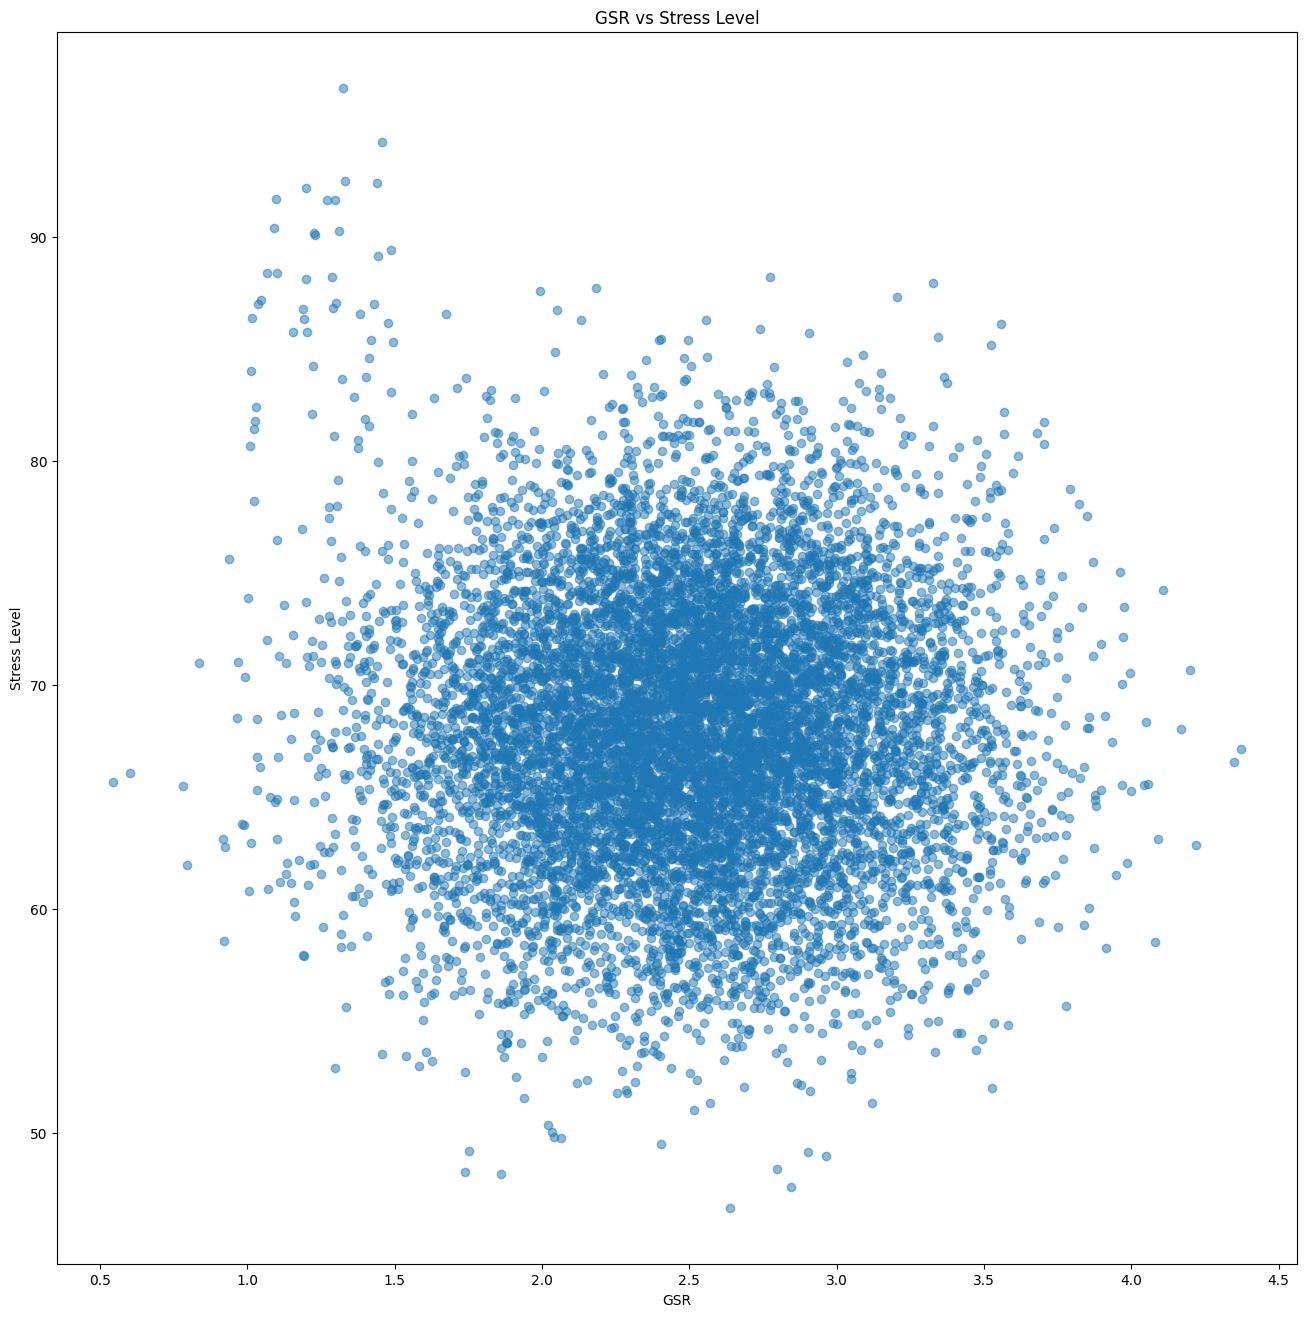

In [61]:
# Create scatterplots for numerical attributes
plt.figure(figsize=(16,16))


plt.scatter(dataset['gsr'], dataset['stress_level'], alpha=0.5)
plt.title('GSR vs Stress Level')
plt.xlabel('GSR')
plt.ylabel('Stress Level')


Text(0, 0.5, 'Stress Level')

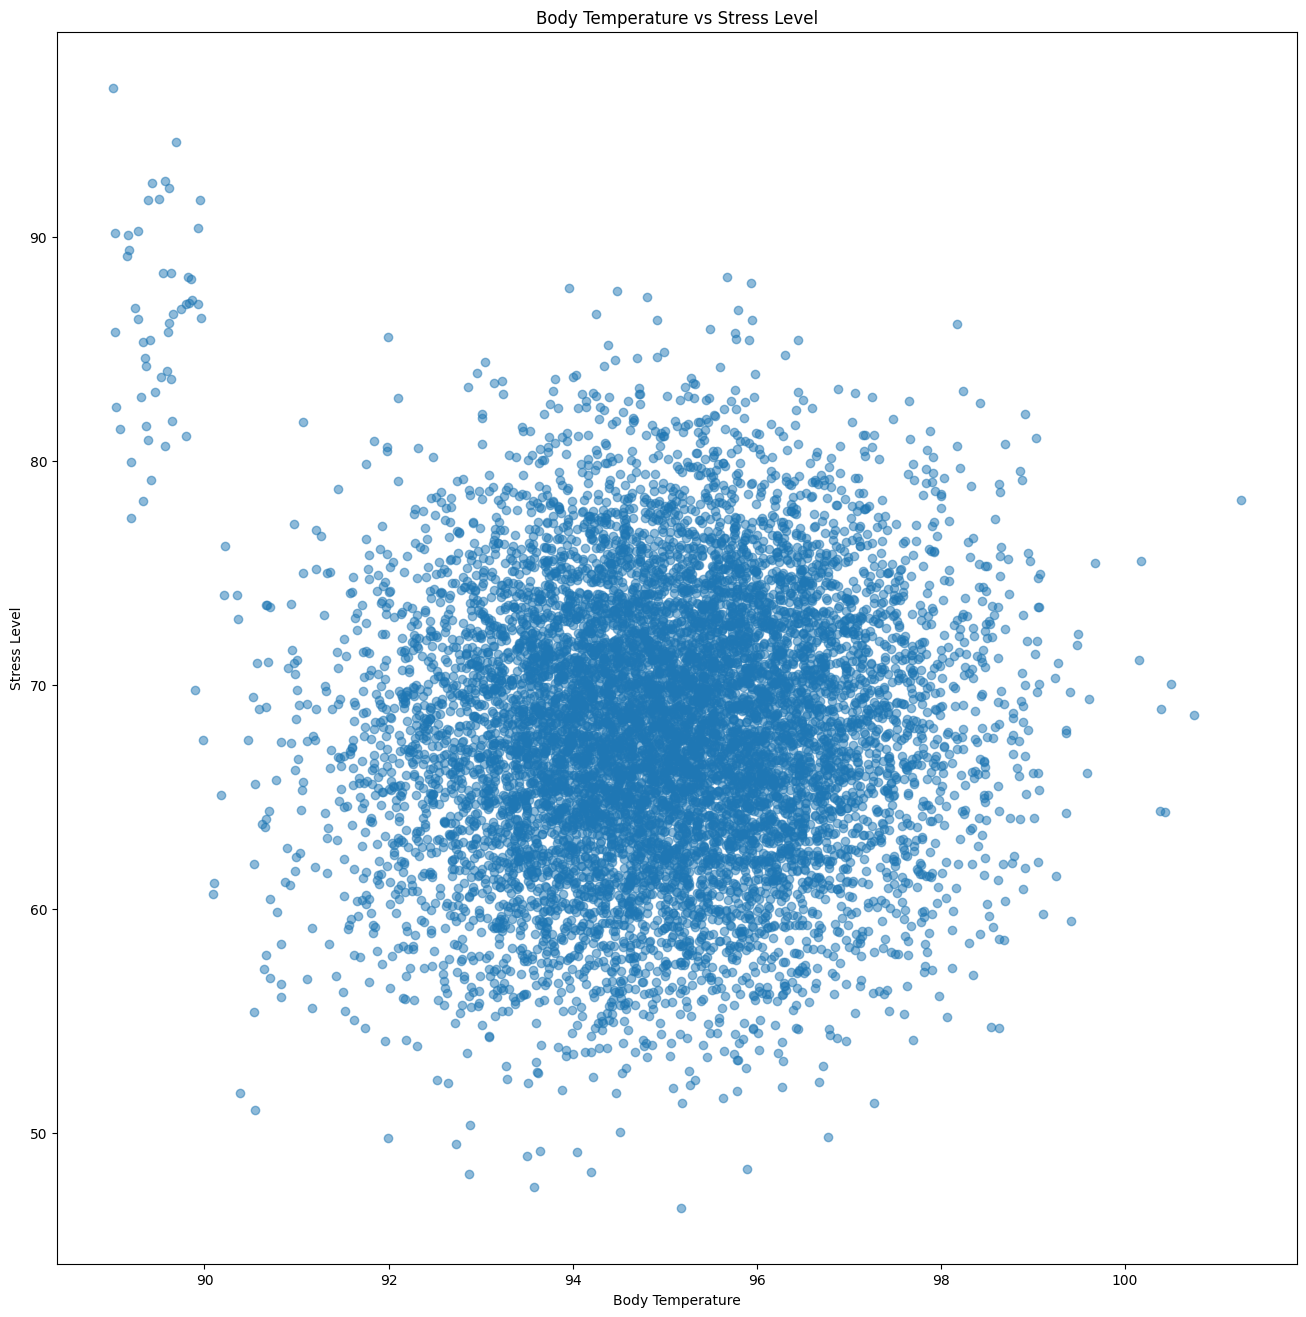

In [62]:

plt.figure(figsize=(16,16))
plt.scatter(dataset['b_temp'], dataset['stress_level'], alpha=0.5)
plt.title('Body Temperature vs Stress Level')
plt.xlabel('Body Temperature')
plt.ylabel('Stress Level')


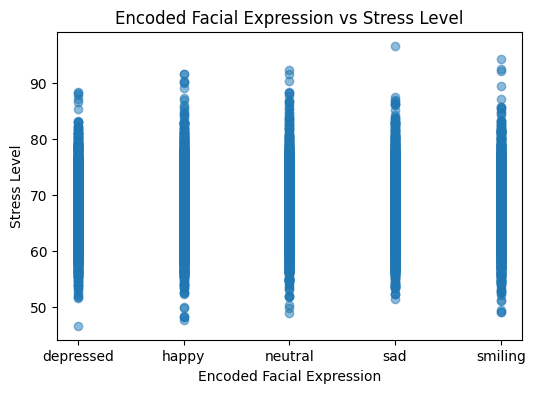

In [63]:
# Encode the categorical attribute 'f_ex' into numerical values
import pandas as pd
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
dataset['f_ex_encoded'] = label_encoder.fit_transform(dataset['f_ex'])

# Create scatterplots for encoded facial expressions against stress levels
plt.figure(figsize=(6, 4))
plt.scatter(dataset['f_ex_encoded'], dataset['stress_level'], alpha=0.5)
plt.title('Encoded Facial Expression vs Stress Level')
plt.xlabel('Encoded Facial Expression')
plt.ylabel('Stress Level')
plt.xticks(range(5), label_encoder.classes_)  # Label the x-axis with facial expressions
plt.show()


Text(0, 0.5, 'Stress Level')

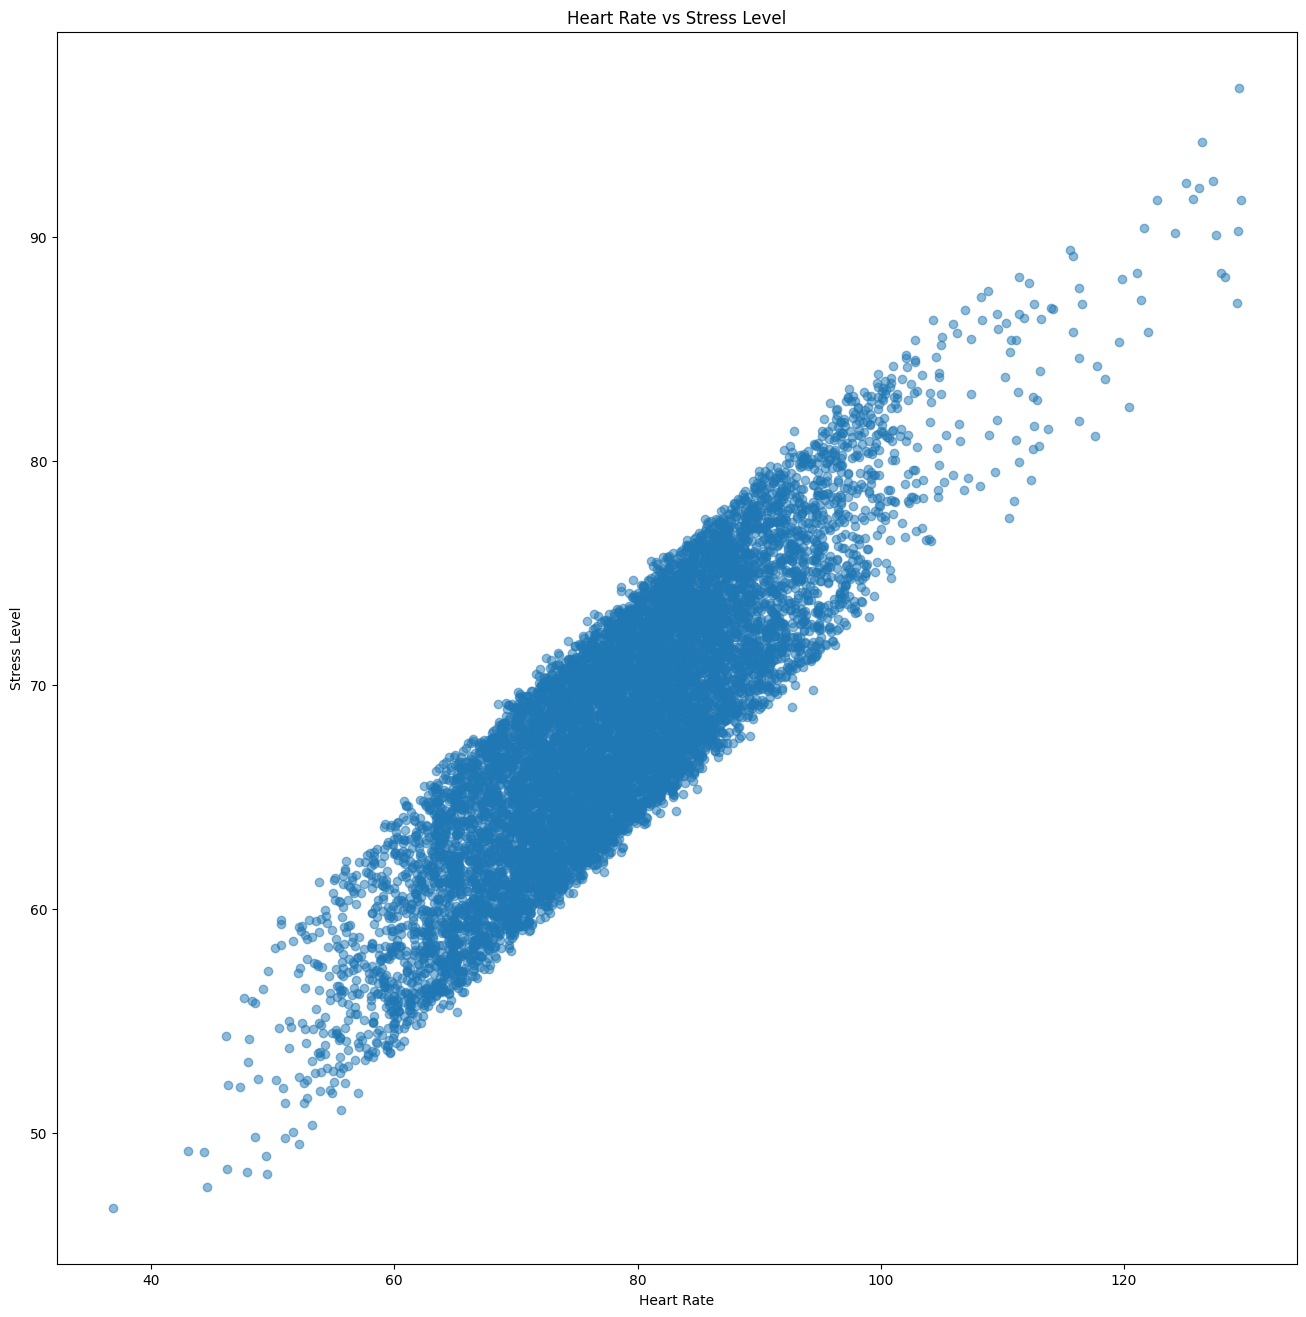

In [64]:
plt.figure(figsize=(16, 16))
plt.scatter(dataset['hr'], dataset['stress_level'], alpha=0.5)
plt.title('Heart Rate vs Stress Level')
plt.xlabel('Heart Rate')
plt.ylabel('Stress Level')


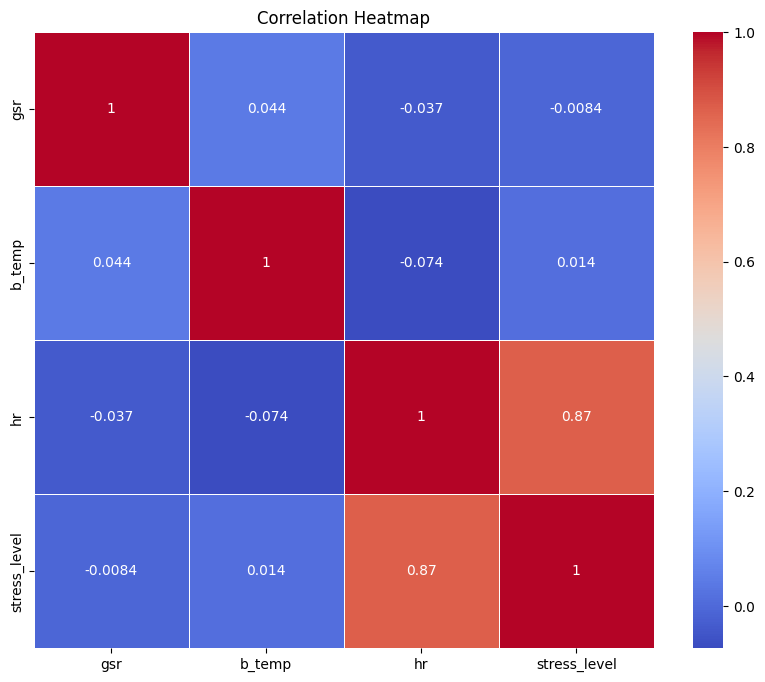

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset with expression variations
dataset = pd.read_csv("realistic_stress_dataset_with_outliers.csv")

# Encode the categorical attribute 'f_ex' into numerical values
label_encoder = LabelEncoder()
dataset['f_ex_encoded'] = label_encoder.fit_transform(dataset['f_ex'])

# Calculate the correlation matrix for numeric attributes
numeric_attributes = dataset[['gsr', 'b_temp', 'hr', 'stress_level']]
correlation_matrix = numeric_attributes.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [74]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Load the dataset with expression variations
dataset = pd.read_csv("realistic_stress_dataset_with_outliers.csv")

# Separate the target variable and attributes
X = dataset.drop(columns=["stress_level"])
y = dataset["stress_level"]

# Perform one-hot encoding on categorical attributes
X_encoded = pd.get_dummies(X, columns=["f_ex"])

# Initialize and train a random forest regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_encoded, y)

# Get feature importances from the trained model
feature_importances = rf_regressor.feature_importances_

# Find the most influential attribute
most_influential_index = feature_importances.argmax()
most_influential_attribute = X_encoded.columns[most_influential_index]

print(f"The most influential attribute is '{most_influential_attribute}' with feature importance of {feature_importances[most_influential_index]:.2f}")


The most influential attribute is 'hr' with feature importance of 0.83


In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load the dataset with expression variations
dataset = pd.read_csv("realistic_stress_dataset_with_outliers.csv")

# Separate the target variable and attributes
X = dataset.drop(columns=["stress_level"])
y = dataset["stress_level"]

# Perform one-hot encoding on categorical attributes
X_encoded = pd.get_dummies(X, columns=["f_ex"])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize and train a random forest regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict stress levels on the test set
y_pred = rf_regressor.predict(X_test)

# Evaluate the model's performance using Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 9.530280210063143


In [77]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print("-"*100)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")
print("-"*100)


# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print("-"*100)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print("-"*100)


# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R^2) Score: {r2}")


Mean Squared Error: 9.530280210063143
----------------------------------------------------------------------------------------------------
Root Mean Squared Error: 3.0871151922244726
----------------------------------------------------------------------------------------------------
Mean Absolute Error: 2.6290840950840675
----------------------------------------------------------------------------------------------------
Mean Absolute Error: 2.6290840950840675
----------------------------------------------------------------------------------------------------
R-squared (R^2) Score: 0.7402720132320926
